/tmp/ipykernel_45714/3552949889.py:44: RuntimeWarning: invalid value encountered in sqrt
  vel_c3 = np.sqrt(10*(-dphi_x3*x - dphi_y3*y))


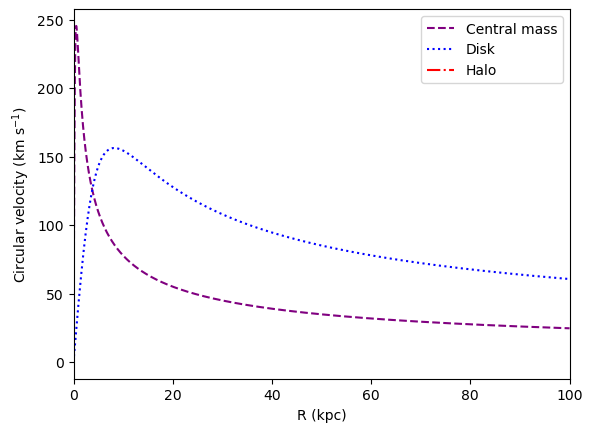

In [16]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.001,100,10000) # kpc units
y = np.linspace(0.001,100,10000)
z = np.zeros(10000)

R = np.sqrt(x**2 + y**2) # kpc units

# Central mass
M1 = 606.
b1 = 0.3873

dphi_x1 =  M1*x/(x**2 + y**2 +b1**2)**(3/2)
dphi_y1 =  M1*y/(x**2 + y**2 + b1**2)**(3/2) 

vel_c1 = np.sqrt(100*(dphi_x1*x + dphi_y1*y)) # km/s

# Disk component
M2 = 3690.
a2 = 5.3178
b2 = 0.25

dphi_x2 = M2*x / (x**2 + y**2 + (a2 + np.sqrt(z**2 + b2))**2)**(3/2)
dphi_y2 = M2*y / (x**2 + y**2 + (a2 + np.sqrt(z**2 + b2))**2)**(3/2)

vel_c2 = np.sqrt(100*(dphi_x2*x + dphi_y2*y)) # km/s

# Halo
M3 = 4615.
a3 = 12.

a = (-1.02*M3*x/R)*(R/a3)**2.02
b = R*(1+(R/a3)**1.02)

c = 2.02*(M3/a3)*(R/a3)**0.02
d = 1/(1 + (R/a3)**1.02)

term1 = a/b**2
term2 = c*d*(x/R)**2
dphi_x3 = (term1 + term2)
dphi_y3 = dphi_x3

vel_c3 = np.sqrt(10*(-dphi_x3*x - dphi_y3*y))

plt.plot(R, vel_c1, color = "purple", label = "Central mass", linestyle = "dashed")
plt.plot(R, vel_c2, color = "blue", label = "Disk", linestyle = "dotted")
plt.plot(R, vel_c3, color = "red", label = "Halo", linestyle = "dashdot")
#plt.plot(R, v, color = "k", label = "Total rotation curve")

plt.xlabel("R (kpc)")
plt.ylabel("Circular velocity (km s$^{-1}$)")
plt.xlim(0,100)
#plt.ylim(0,350)
plt.legend()
plt.show()

In [28]:
np.sum(a > 0), np.sum(b > 0)

(np.int64(0), np.int64(10000))

In [29]:
np.sum(c > 0), np.sum(d > 0)

(np.int64(10000), np.int64(10000))

In [24]:
len(d)

10000

In [22]:
c

array([648.28877777, 680.13804418, 688.99113533, ..., 816.14395132,
       816.145584  , 816.14721652])